### <h4 style="color:blue;">01 dependencies</h5>

In [52]:
# standard library
import os
import random
from collections import Counter

# data handling
import pandas as pd

# image processing
from PIL import Image
import cv2

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# deep learning
import torch
from facenet_pytorch import MTCNN

# utilities
from tqdm import tqdm
import hashlib

In [ ]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [62]:
# base path
TRAIN_PATH = "../data/train"
TEST_PATH  = "../data/test"
TRAIN_CLEAN_PATH = '../data/cropped'
TEST_CLEAN_PATH = '../data/cropped_test'
input_dir = '../data/train'
output_dir = '../data/cropped'

### <h4 style="color:blue;">02 cropping image</h5>

In [42]:
# Inisialisasi MTCNN
mtcnn = MTCNN(
    image_size=224,
    keep_all=False,       
    select_largest=True,  
    margin=60,            
    post_process=False,   
    device=device
)

> train

In [43]:
classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

def center_crop(img, size=224):
    w, h = img.size
    min_dim = min(w, h)

    left = (w - min_dim) // 2
    top = (h - min_dim) // 2
    right = left + min_dim
    bottom = top + min_dim

    img = img.crop((left, top, right, bottom))
    return img.resize((size, size))

for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

total_images = 0
successful_crops = 0
fallback_used = 0

for cls in classes:
    class_input_path = os.path.join(input_dir, cls)
    class_output_path = os.path.join(output_dir, cls)
    
    if not os.path.exists(class_input_path):
        print(f"Folder {cls} tidak ditemukan, skip.")
        continue
        
    images = os.listdir(class_input_path)
    print(f"\nMemproses: {cls} ({len(images)} gambar)")
    
    for img_name in tqdm(images):
        total_images += 1
        img_path = os.path.join(class_input_path, img_name)
        out_path = os.path.join(class_output_path, img_name)
        
        try:
            img = Image.open(img_path).convert('RGB')

            # === MTCNN ===
            face = mtcnn(img)

            if face is not None:
                # save tensor ke image
                face_img = Image.fromarray(face.permute(1,2,0).byte().cpu().numpy())
                face_img.save(out_path)
                successful_crops += 1

            else:
                # === FALLBACK CENTER CROP ===
                fallback_img = center_crop(img, size=224)
                fallback_img.save(out_path)
                fallback_used += 1

        except Exception as e:
            # fallback kalau error juga
            fallback_img = center_crop(img, size=224)
            fallback_img.save(out_path)
            fallback_used += 1

print("\n" + "="*30)
print("Ringkasan Cropping")
print(f"Total gambar: {total_images}")
print(f"MTCNN berhasil: {successful_crops}")
print(f"Fallback (center crop): {fallback_used}")
print("="*30)


Memproses: realperson (437 gambar)


100%|██████████| 437/437 [08:34<00:00,  1.18s/it]



Memproses: fake_mask (267 gambar)


100%|██████████| 267/267 [03:53<00:00,  1.15it/s]



Memproses: fake_printed (138 gambar)


...


Memproses: fake_mannequin (229 gambar)


100%|██████████| 229/229 [01:36<00:00,  2.37it/s]



Memproses: fake_unknown (367 gambar)


100%|██████████| 367/367 [00:57<00:00,  6.35it/s]


Ringkasan Cropping
Total gambar: 1645
MTCNN berhasil: 1524
Fallback (center crop): 121


> test

In [44]:
# base path
input_test_dir = '../data/test'
output_test_dir = '../data/cropped_test'

In [45]:
os.makedirs(output_test_dir, exist_ok=True)

total_images = 0
successful_crops = 0
fallback_used = 0

def center_crop(img, size=224):
    w, h = img.size
    min_dim = min(w, h)

    left = (w - min_dim) // 2
    top = (h - min_dim) // 2
    right = left + min_dim
    bottom = top + min_dim

    img = img.crop((left, top, right, bottom))
    return img.resize((size, size))

images = os.listdir(input_test_dir)
print(f"Total gambar test: {len(images)}")

for img_name in tqdm(images):
    img_path = os.path.join(input_test_dir, img_name)
    out_path = os.path.join(output_test_dir, img_name)

    # skip kalau bukan image
    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    total_images += 1

    try:
        img = Image.open(img_path).convert('RGB')

        # === MTCNN ===
        face = mtcnn(img)

        if face is not None:
            # save tensor ke image
            face_img = Image.fromarray(face.permute(1,2,0).byte().cpu().numpy())
            face_img.save(out_path)
            successful_crops += 1

        else:
            # === FALLBACK CENTER CROP ===
            fallback_img = center_crop(img, size=224)
            fallback_img.save(out_path)
            fallback_used += 1

    except Exception as e:
        fallback_img = center_crop(img, size=224)
        fallback_img.save(out_path)
        fallback_used += 1

print("\n" + "="*30)
print("Ringkasan Cropping (TEST)")
print(f"Total gambar: {total_images}")
print(f"MTCNN berhasil: {successful_crops}")
print(f"Fallback (center crop): {fallback_used}")
print("="*30)

Total gambar test: 404


100%|██████████| 404/404 [04:42<00:00,  1.43it/s]


Ringkasan Cropping (TEST)
Total gambar: 404
MTCNN berhasil: 382
Fallback (center crop): 22


### <h4 style="color:blue;">03 buat dataset</h5>

In [53]:
classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

CROP_PATH = "../data/cropped"

data = []

for cls in classes:
    cls_path = os.path.join(CROP_PATH, cls)
    
    if not os.path.exists(cls_path):
        continue
    
    for file in os.listdir(cls_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(cls_path, file)
            
            data.append({
                "image_path": img_path,
                "label": cls
            })

df_train = pd.DataFrame(data)

print(df_train.head())
print("Total train:", len(df_train))

                                image_path       label
0  ../data/cropped\realperson\mask_050.jpg  realperson
1  ../data/cropped\realperson\mask_233.jpg  realperson
2  ../data/cropped\realperson\real_001.jpg  realperson
3  ../data/cropped\realperson\real_002.jpg  realperson
4  ../data/cropped\realperson\real_003.jpg  realperson
Total train: 1645


In [48]:
CROP_TEST_PATH = "../data/cropped_test"

data_test = []

for file in os.listdir(CROP_TEST_PATH):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(CROP_TEST_PATH, file)
        
        data_test.append({
            "image_path": img_path
        })

df_test = pd.DataFrame(data_test)

print(df_test.head())
print("Total test:", len(df_test))

                          image_path
0  ../data/cropped_test\test_001.jpg
1  ../data/cropped_test\test_002.jpg
2  ../data/cropped_test\test_003.jpg
3  ../data/cropped_test\test_004.jpg
4  ../data/cropped_test\test_005.jpg
Total test: 404


### <h4 style="color:blue;">04 handle data duplikat</h5>

In [54]:
def file_md5(path: str, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    try:
        with open(path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                h.update(chunk)
        return h.hexdigest()
    except:
        return None


hash_df = df_train.copy()
hash_df["md5"] = hash_df["image_path"].apply(file_md5)

# drop gagal baca
hash_df = hash_df.dropna(subset=["md5"])

# cari duplicate
dup_train = hash_df[
    hash_df.duplicated(subset=["md5"], keep=False)
].sort_values("md5")

print("=== DUPLICATE TRAIN ===")
print(f"Total data     : {len(hash_df)}")
print(f"Duplicate rows : {len(dup_train)}")

display(dup_train.head(20))

=== DUPLICATE TRAIN ===
Total data     : 1645
Duplicate rows : 332


,image_path,label,md5
1255,../data/cropped\fake_mannequin\mannequin_223.jpg,fake_mannequin,03836348a13a7955b04a6eb966fed253
1264,../data/cropped\fake_mannequin\screen_105.jpg,fake_mannequin,03836348a13a7955b04a6eb966fed253
1293,../data/cropped\fake_unknown\printed_012.jpeg,fake_unknown,0b077e32fd1c5a50d699483fce9d9abf
1462,../data/cropped\fake_unknown\unknown_139.jpeg,fake_unknown,0b077e32fd1c5a50d699483fce9d9abf
850,../data/cropped\fake_screen\real_382.jpg,fake_screen,0cc109bd5126b8af8e08646b3eed8b34
791,../data/cropped\fake_printed\printed_074.jpg,fake_printed,0cc109bd5126b8af8e08646b3eed8b34
1262,../data/cropped\fake_mannequin\screen_067.jpg,fake_mannequin,0e69e936dc9ae993c8ca1ae9ccd7dd08
1156,../data/cropped\fake_mannequin\mannequin_116.jpg,fake_mannequin,0e69e936dc9ae993c8ca1ae9ccd7dd08
340,../data/cropped\realperson\real_374.jpg,realperson,111f5f50a24a0519bf700f0e7ff89efe
418,../data/cropped\realperson\screen_018.jpg,realperson,111f5f50a24a0519bf700f0e7ff89efe


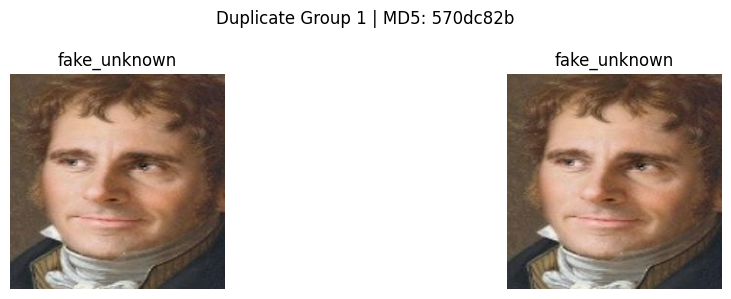

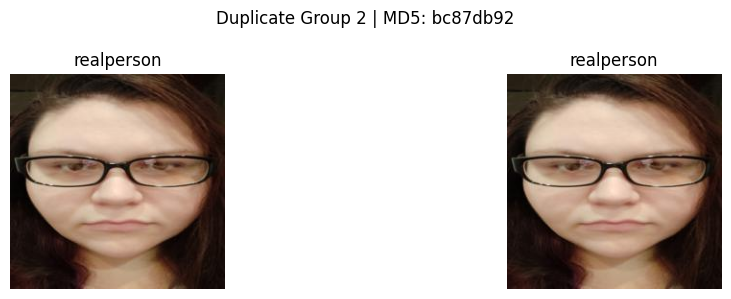

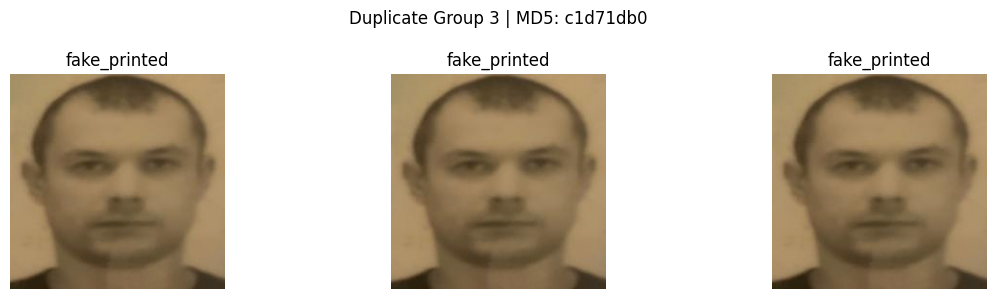

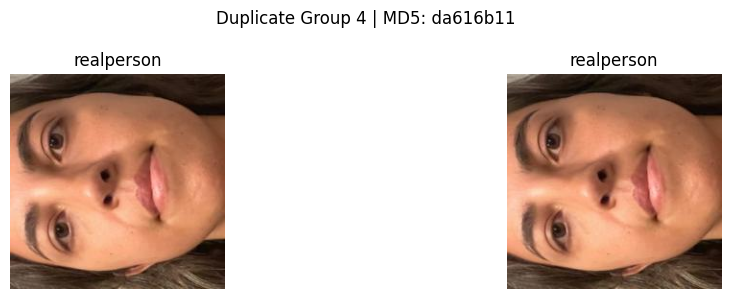

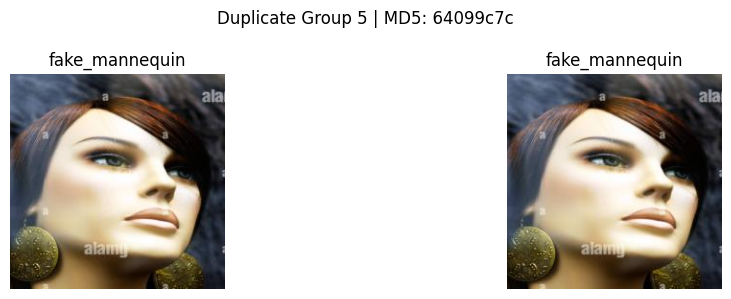

In [55]:
# show data duplikat

dup_groups = dup_train.groupby("md5")

def show_duplicate_images_random(dup_groups, max_groups=5):
    groups_list = list(dup_groups)

    if len(groups_list) == 0:
        print("No duplicates found")
        return

    sampled_groups = random.sample(groups_list, min(max_groups, len(groups_list)))

    for i, (md5, group) in enumerate(sampled_groups):
        paths = group["image_path"].tolist()
        labels = group["label"].tolist()

        plt.figure(figsize=(12, 3))
        plt.suptitle(f"Duplicate Group {i+1} | MD5: {md5[:8]}")

        for j, (path, label) in enumerate(zip(paths, labels)):
            try:
                img = Image.open(path)

                plt.subplot(1, len(paths), j+1)
                plt.imshow(img)
                plt.title(label)
                plt.axis('off')
            except:
                continue

        plt.tight_layout()
        plt.show()

# run
show_duplicate_images_random(dup_groups, max_groups=5)

In [56]:
# hapus duplikatnya
train_df_clean = hash_df.drop_duplicates(subset=["md5"], keep="first")

# sisanya = yang akan dihapus
to_delete = hash_df[~hash_df.index.isin(train_df_clean.index)]

print("File yang akan dihapus:", len(to_delete))

for path in to_delete["image_path"]:  # ✅ fix kolom
    try:
        os.remove(path)
    except Exception as e:
        print("Gagal hapus:", path, "|", e)

print("Hapus duplicate selesai ✅")

File yang akan dihapus: 174
Hapus duplicate selesai ✅


### <h4 style="color:blue;">04 anomali dalam dataset</h5>

In [65]:
VALID_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def scan_anomalies(base_path, is_train=True):
    bad_files = []
    total_files = 0

    if is_train:
        # ada class folder
        for class_name in os.listdir(base_path):
            class_path = os.path.join(base_path, class_name)

            if not os.path.isdir(class_path):
                continue

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)

                if not img_name.lower().endswith(VALID_EXT):
                    continue

                total_files += 1

                try:
                    img = Image.open(img_path)

                    # cek 1: bisa dibuka
                    img.verify()  # penting: detect corrupt

                    # buka ulang setelah verify
                    img = Image.open(img_path)

                    # cek 2: mode aneh
                    if img.mode not in ["RGB", "L"]:
                        bad_files.append((img_path, f"mode: {img.mode}"))
                        continue

                    # cek 3: ukuran aneh
                    if img.size[0] < 10 or img.size[1] < 10:
                        bad_files.append((img_path, f"too small: {img.size}"))
                        continue

                except Exception as e:
                    bad_files.append((img_path, "corrupt / unreadable"))

    else:
        # test biasanya tanpa class folder
        for img_name in os.listdir(base_path):
            img_path = os.path.join(base_path, img_name)

            if not img_name.lower().endswith(VALID_EXT):
                continue

            total_files += 1

            try:
                img = Image.open(img_path)
                img.verify()

                img = Image.open(img_path)

                if img.mode not in ["RGB", "L"]:
                    bad_files.append((img_path, f"mode: {img.mode}"))
                    continue

                if img.size[0] < 10 or img.size[1] < 10:
                    bad_files.append((img_path, f"too small: {img.size}"))
                    continue

            except Exception as e:
                bad_files.append((img_path, "corrupt / unreadable"))

    return total_files, bad_files


# ===== RUN =====
train_total, train_bad = scan_anomalies(TRAIN_CLEAN_PATH, is_train=True)
test_total, test_bad   = scan_anomalies(TEST_CLEAN_PATH, is_train=False)

# ===== PRINT =====
print("\n=== TRAIN ===")
print("Total files:", train_total)
print("Anomalies:", len(train_bad))

for path, reason in train_bad:
    print(f"[TRAIN] {reason} -> {path}")

print("\n=== TEST ===")
print("Total files:", test_total)
print("Anomalies:", len(test_bad))

for path, reason in test_bad:
    print(f"[TEST] {reason} -> {path}")


=== TRAIN ===
Total files: 1471
Anomalies: 0

=== TEST ===
Total files: 404
Anomalies: 0
